# Version 21.2 : CoxNet with Automatic Feature Selection

**Objectif** : Optimiser le nombre de features pour maximiser la généralisation

**Stratégie** :
- 🔍 Utiliser les features enrichies de V21.1 (base: 0.7493 C-index)
- 📊 Tester plusieurs seuils : top 30, 50, 70, 100, 150 features
- 🎯 Sélectionner le meilleur compromis biais/variance
- ⚡ Réduire le bruit et améliorer la généralisation

**Amélioration attendue** : +0.005-0.015 C-index par réduction du bruit

## 1. Setup & Imports

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Survival analysis
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Set random seed
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 2. Data Loading

In [2]:
# Load data
import os
DATA_PATH = "C:/Users/guill/Desktop/Data Challenge QRT/Data-Challenge-Prediction-de-Survie"

clinical_train = pd.read_csv(os.path.join(DATA_PATH, "X_train", "clinical_train.csv"))
target_train = pd.read_csv(os.path.join(DATA_PATH, "target_train.csv"))
clinical_test = pd.read_csv(os.path.join(DATA_PATH, "X_test", "clinical_test.csv"))
molecular_train = pd.read_csv(os.path.join(DATA_PATH, "X_train", "molecular_train.csv"))
molecular_test = pd.read_csv(os.path.join(DATA_PATH, "X_test", "molecular_test.csv"))

print(f"✓ Data loaded: {clinical_train.shape[0]} train patients")
print(f"  Test patients: {clinical_test.shape[0]}")

✓ Data loaded: 3323 train patients
  Test patients: 1193


## 3. Feature Engineering (same as V21.1)

In [3]:
# Copy all feature engineering from V21.1
def create_cytogenetic_features(clinical_df):
    """Create cytogenetic features from CYTOGENETICS column"""
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    """Create molecular features"""
    mol_features = pd.DataFrame({'ID': patient_ids})
    
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

def add_enriched_features(X_clinical, X_molecular):
    """Add enriched features for linear models"""
    X_enriched = pd.DataFrame(index=X_clinical.index)
    
    # Non-linear transformations
    for col in ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES']:
        if col in X_clinical.columns:
            X_enriched[f'{col}_log'] = np.log1p(X_clinical[col])
            X_enriched[f'{col}_sqrt'] = np.sqrt(X_clinical[col].clip(lower=0))
            X_enriched[f'{col}_squared'] = X_clinical[col] ** 2
    
    # Clinical ratios
    if 'WBC' in X_clinical.columns and 'ANC' in X_clinical.columns:
        X_enriched['WBC_ANC_ratio'] = X_clinical['WBC'] / (X_clinical['ANC'] + 1e-5)
    if 'HB' in X_clinical.columns and 'PLT' in X_clinical.columns:
        X_enriched['HB_PLT_ratio'] = X_clinical['HB'] / (X_clinical['PLT'] + 1e-5)
    if 'WBC' in X_clinical.columns and 'MONOCYTES' in X_clinical.columns:
        X_enriched['WBC_MONOCYTES_ratio'] = X_clinical['WBC'] / (X_clinical['MONOCYTES'] + 1e-5)
    if 'BM_BLAST' in X_clinical.columns and 'WBC' in X_clinical.columns:
        X_enriched['BLAST_WBC_ratio'] = X_clinical['BM_BLAST'] / (X_clinical['WBC'] + 1e-5)
    
    # Clinical interactions
    important_pairs = [
        ('BM_BLAST', 'WBC'), ('BM_BLAST', 'HB'), ('BM_BLAST', 'PLT'),
        ('WBC', 'HB'), ('HB', 'PLT'), ('ANC', 'MONOCYTES')
    ]
    for col1, col2 in important_pairs:
        if col1 in X_clinical.columns and col2 in X_clinical.columns:
            X_enriched[f'{col1}_x_{col2}'] = X_clinical[col1] * X_clinical[col2]
    
    # Molecular × Clinical interactions
    if 'mutation_count_total' in X_molecular.columns:
        if 'BM_BLAST' in X_clinical.columns:
            X_enriched['mutations_x_BLAST'] = X_molecular['mutation_count_total'] * X_clinical['BM_BLAST']
        if 'WBC' in X_clinical.columns:
            X_enriched['mutations_x_WBC'] = X_molecular['mutation_count_total'] * X_clinical['WBC']
    if 'vaf_sum' in X_molecular.columns and 'BM_BLAST' in X_clinical.columns:
        X_enriched['vaf_sum_x_BLAST'] = X_molecular['vaf_sum'] * X_clinical['BM_BLAST']
    
    # Binning
    if 'BM_BLAST' in X_clinical.columns:
        X_enriched['BLAST_low'] = (X_clinical['BM_BLAST'] < 20).astype(int)
        X_enriched['BLAST_high'] = (X_clinical['BM_BLAST'] >= 50).astype(int)
    
    return X_enriched

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


## 4. Build All Features (same as V21.1)

In [4]:
# Build all features exactly like V21.1
target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_clinical_train = clinical_train_clean[numeric_features].copy()
center_encoded_train = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical_train = pd.concat([X_clinical_train, center_encoded_train], axis=1)

cyto_features_train = create_cytogenetic_features(clinical_train)
train_patient_ids = clinical_train_clean.index.unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids, top_n_genes=20)
mol_features_train_aligned = mol_features_train.reindex(X_clinical_train.index, fill_value=0)

enriched_features_train = add_enriched_features(X_clinical_train[numeric_features], mol_features_train_aligned)

cyto_features_train_aligned = cyto_features_train.reindex(X_clinical_train.index, fill_value=0)
X_combined_train = pd.concat([
    X_clinical_train, mol_features_train_aligned, cyto_features_train_aligned, enriched_features_train
], axis=1)

# Test set
X_clinical_test = clinical_test.set_index('ID')[numeric_features].copy()
center_encoded_test = pd.get_dummies(clinical_test.set_index('ID')['CENTER'], prefix='CENTER', drop_first=True)
X_clinical_test = pd.concat([X_clinical_test, center_encoded_test], axis=1)

for col in X_clinical_train.columns:
    if col not in X_clinical_test.columns:
        X_clinical_test[col] = 0
X_clinical_test = X_clinical_test[X_clinical_train.columns]

cyto_features_test = create_cytogenetic_features(clinical_test)
test_patient_ids = clinical_test['ID'].unique()
mol_features_test = create_molecular_features(molecular_test, test_patient_ids, top_n_genes=20)

for col in mol_features_train.columns:
    if col not in mol_features_test.columns:
        mol_features_test[col] = 0
mol_features_test = mol_features_test[mol_features_train.columns]

mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
enriched_features_test = add_enriched_features(X_clinical_test[numeric_features], mol_features_test_aligned)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)

X_combined_test = pd.concat([
    X_clinical_test, mol_features_test_aligned, cyto_features_test_aligned, enriched_features_test
], axis=1)

print(f"✓ Features built: {X_combined_train.shape}")

✓ Features built: (3173, 132)


## 5. Preprocessing

In [5]:
imputer = SimpleImputer(strategy='median')
X_imputed_train = pd.DataFrame(
    imputer.fit_transform(X_combined_train),
    index=X_combined_train.index,
    columns=X_combined_train.columns
)

X_imputed_test = pd.DataFrame(
    imputer.transform(X_combined_test),
    index=X_combined_test.index,
    columns=X_combined_test.columns
)

scaler = StandardScaler()
X_scaled_train = pd.DataFrame(
    scaler.fit_transform(X_imputed_train),
    index=X_imputed_train.index,
    columns=X_imputed_train.columns
)

X_scaled_test = pd.DataFrame(
    scaler.transform(X_imputed_test),
    index=X_imputed_test.index,
    columns=X_imputed_test.columns
)

y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_train, y_surv, test_size=0.2, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"✓ Data preprocessed: {X_train.shape[1]} total features")

✓ Data preprocessed: 132 total features


## 6. Step 1: Get Feature Importance from Full Model

In [6]:
print("="*60)
print("STEP 1: TRAINING FULL MODEL TO GET FEATURE IMPORTANCE")
print("="*60)

# Train with best params from V21.1 (adjust if needed)
coxnet_full = CoxnetSurvivalAnalysis(
    l1_ratio=0.7,  # Use best from V21.1
    alphas=[0.01],  # Use best from V21.1
    max_iter=100000,
    fit_baseline_model=True
)

coxnet_full.fit(X_train.values, y_train)

y_pred_val_full = coxnet_full.predict(X_val.values)
c_index_full = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_full
)[0]

print(f"\n✓ Full model trained")
print(f"  Baseline C-index (all {X_train.shape[1]} features): {c_index_full:.4f}")
print(f"  Features with non-zero coef: {np.sum(coxnet_full.coef_.flatten() != 0)}")

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coxnet_full.coef_.flatten()
})
feature_importance['abs_coef'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance[['feature', 'coefficient']].head(10).to_string(index=False))

STEP 1: TRAINING FULL MODEL TO GET FEATURE IMPORTANCE

✓ Full model trained
  Baseline C-index (all 132 features): 0.7369
  Features with non-zero coef: 73

Top 10 most important features:
             feature  coefficient
                  HB    -0.230588
        BM_BLAST_log     0.169241
mutation_count_total     0.156724
         cyto_normal    -0.148293
     gene_TP53_count     0.130645
             vaf_max     0.121209
   mutations_x_BLAST    -0.117142
          effect_PTD     0.109633
            HB_x_PLT    -0.089167
          CENTER_MUV     0.089117


## 7. Step 2: Test Multiple Feature Selection Thresholds

In [7]:
print("\n" + "="*60)
print("STEP 2: TESTING MULTIPLE FEATURE SELECTION THRESHOLDS")
print("="*60)

# Test different numbers of top features
n_features_to_test = [30, 50, 70, 100, 150]
selection_results = []

for n_top in n_features_to_test:
    # Select top N features
    top_features = feature_importance.head(n_top)['feature'].tolist()
    
    # Subset data
    X_train_subset = X_train[top_features]
    X_val_subset = X_val[top_features]
    
    # Train model on subset
    coxnet_subset = CoxnetSurvivalAnalysis(
        l1_ratio=0.7,
        alphas=[0.01],
        max_iter=100000,
        fit_baseline_model=True
    )
    
    coxnet_subset.fit(X_train_subset.values, y_train)
    
    # Evaluate
    y_pred_train_subset = coxnet_subset.predict(X_train_subset.values)
    y_pred_val_subset = coxnet_subset.predict(X_val_subset.values)
    
    c_index_train = concordance_index_censored(
        y_train['OS_STATUS'], y_train['OS_YEARS'], y_pred_train_subset
    )[0]
    
    c_index_val = concordance_index_censored(
        y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_subset
    )[0]
    
    selection_results.append({
        'n_features': n_top,
        'c_index_train': c_index_train,
        'c_index_val': c_index_val,
        'improvement_vs_full': c_index_val - c_index_full,
        'overfitting': c_index_train - c_index_val
    })
    
    print(f"Top {n_top:3d} features | Train: {c_index_train:.4f} | "
          f"Val: {c_index_val:.4f} | Δ vs full: {c_index_val - c_index_full:+.4f}")

results_df = pd.DataFrame(selection_results)

print("\n" + "="*60)
print("SUMMARY OF ALL CONFIGURATIONS")
print("="*60)
print(results_df.to_string(index=False))

# Find best
best_idx = results_df['c_index_val'].idxmax()
best_n_features = results_df.loc[best_idx, 'n_features']
best_c_index = results_df.loc[best_idx, 'c_index_val']
improvement = results_df.loc[best_idx, 'improvement_vs_full']

print(f"\n🏆 BEST CONFIGURATION:")
print(f"  Number of features: {int(best_n_features)}")
print(f"  Validation C-index: {best_c_index:.4f}")
print(f"  Improvement vs full model: {improvement:+.4f}")
print(f"\n📊 Comparison:")
print(f"  V21.1 (all features): {c_index_full:.4f}")
print(f"  V21.2 (top {int(best_n_features)}):     {best_c_index:.4f} {'⭐' if improvement > 0 else ''}")


STEP 2: TESTING MULTIPLE FEATURE SELECTION THRESHOLDS
Top  30 features | Train: 0.7466 | Val: 0.7338 | Δ vs full: -0.0031
Top  50 features | Train: 0.7502 | Val: 0.7361 | Δ vs full: -0.0008
Top  70 features | Train: 0.7507 | Val: 0.7367 | Δ vs full: -0.0002
Top 100 features | Train: 0.7507 | Val: 0.7367 | Δ vs full: -0.0002
Top 150 features | Train: 0.7507 | Val: 0.7367 | Δ vs full: -0.0002

SUMMARY OF ALL CONFIGURATIONS
 n_features  c_index_train  c_index_val  improvement_vs_full  overfitting
         30       0.746561     0.733821            -0.003081     0.012740
         50       0.750198     0.736129            -0.000773     0.014068
         70       0.750710     0.736706            -0.000195     0.014003
        100       0.750703     0.736697            -0.000205     0.014006
        150       0.750705     0.736706            -0.000195     0.013998

🏆 BEST CONFIGURATION:
  Number of features: 70
  Validation C-index: 0.7367
  Improvement vs full model: -0.0002

📊 Comparison:
 

## 8. Visualization

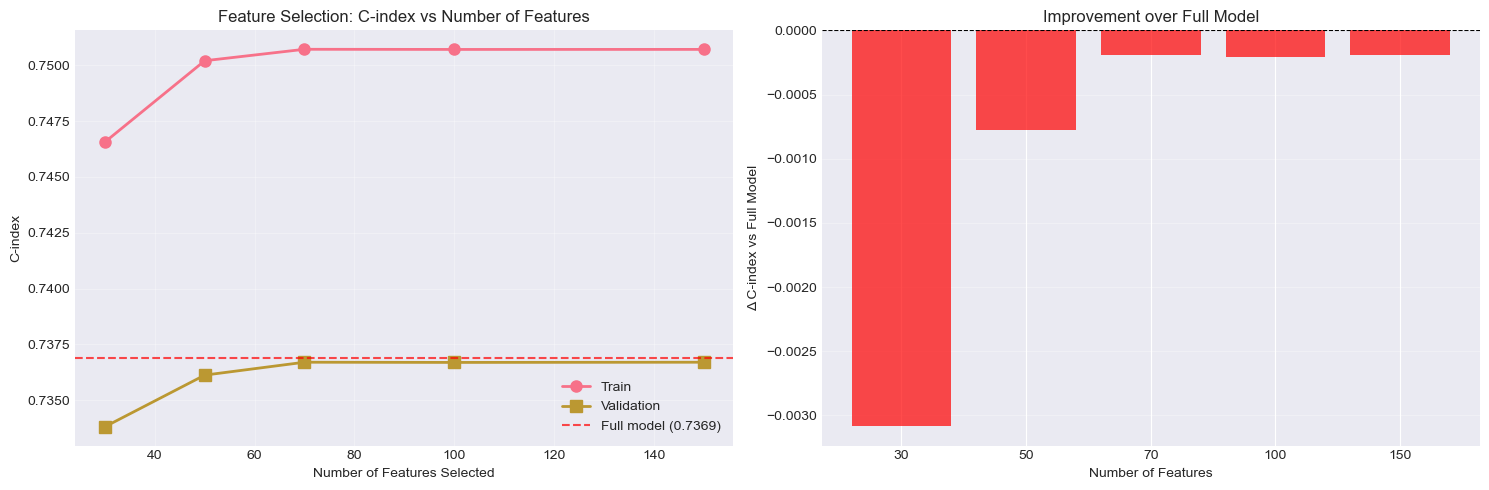

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# C-index vs number of features
ax1.plot(results_df['n_features'], results_df['c_index_train'], 'o-', 
         label='Train', linewidth=2, markersize=8)
ax1.plot(results_df['n_features'], results_df['c_index_val'], 's-', 
         label='Validation', linewidth=2, markersize=8)
ax1.axhline(y=c_index_full, color='r', linestyle='--', 
            label=f'Full model ({c_index_full:.4f})', alpha=0.7)
ax1.set_xlabel('Number of Features Selected')
ax1.set_ylabel('C-index')
ax1.set_title('Feature Selection: C-index vs Number of Features')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Improvement over full model
ax2.bar(range(len(results_df)), results_df['improvement_vs_full'], 
        color=['green' if x > 0 else 'red' for x in results_df['improvement_vs_full']],
        alpha=0.7)
ax2.set_xticks(range(len(results_df)))
ax2.set_xticklabels([f"{int(x)}" for x in results_df['n_features']])
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Δ C-index vs Full Model')
ax2.set_title('Improvement over Full Model')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Train Final Model with Best Number of Features

In [9]:
print("\n" + "="*60)
print("STEP 3: TRAINING FINAL MODEL")
print("="*60)

# Select best features
best_features = feature_importance.head(int(best_n_features))['feature'].tolist()

print(f"\nTop {int(best_n_features)} selected features:")
for i, feat in enumerate(best_features[:20], 1):
    coef = feature_importance[feature_importance['feature'] == feat]['coefficient'].values[0]
    print(f"  {i:2d}. {feat:40s} (coef: {coef:+.4f})")
if best_n_features > 20:
    print(f"  ... and {int(best_n_features) - 20} more")

# Train final model on full training data
X_train_final = X_scaled_train[best_features]
X_test_final = X_scaled_test[best_features]

coxnet_final = CoxnetSurvivalAnalysis(
    l1_ratio=0.7,
    alphas=[0.01],
    max_iter=100000,
    fit_baseline_model=True
)

coxnet_final.fit(X_train_final.values, y_surv)

# Final validation
X_val_final = X_val[best_features]
y_pred_val_final = coxnet_final.predict(X_val_final.values)
c_index_val_final = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_final
)[0]

print(f"\n✓ Final model trained on {int(best_n_features)} features")
print(f"  Final Validation C-index: {c_index_val_final:.4f}")


STEP 3: TRAINING FINAL MODEL

Top 70 selected features:
   1. HB                                       (coef: -0.2306)
   2. BM_BLAST_log                             (coef: +0.1692)
   3. mutation_count_total                     (coef: +0.1567)
   4. cyto_normal                              (coef: -0.1483)
   5. gene_TP53_count                          (coef: +0.1306)
   6. vaf_max                                  (coef: +0.1212)
   7. mutations_x_BLAST                        (coef: -0.1171)
   8. effect_PTD                               (coef: +0.1096)
   9. HB_x_PLT                                 (coef: -0.0892)
  10. CENTER_MUV                               (coef: +0.0891)
  11. gene_ASXL1_present                       (coef: +0.0887)
  12. gene_TP53_present                        (coef: +0.0819)
  13. cyto_del_count                           (coef: +0.0816)
  14. CENTER_PV                                (coef: -0.0795)
  15. BM_BLAST_x_WBC                           (coef: +0.0787

## 10. Predictions & Submission

In [ ]:
# Generate predictions
test_risk_scores = coxnet_final.predict(X_test_final.values)

# Create submission
submission = pd.DataFrame({
    'ID': X_test_final.index,
    'OS_YEARS': test_risk_scores
})

# Save submission
submission_path = os.path.join(DATA_PATH, f"submission_v21.2_coxnet_top{int(best_n_features)}.csv")
submission.to_csv(submission_path, index=False)

print("="*60)
print("SUBMISSION CREATED")
print("="*60)
print(f"✓ File: {submission_path}")
print(f"\nPreview:")
print(submission.head(10))

## 11. Summary

In [ ]:
print("="*60)
print("SUMMARY - CoxNet V21.2 (Feature Selection)")
print("="*60)
print(f"\n🔍 Feature Selection Results:")
print(f"  Original features: {X_train.shape[1]}")
print(f"  Selected features: {int(best_n_features)}")
print(f"  Reduction: {X_train.shape[1] - int(best_n_features)} features removed")
print(f"\n📊 Performance:")
print(f"  V21.1 (all {X_train.shape[1]} features): {c_index_full:.4f}")
print(f"  V21.2 (top {int(best_n_features)} features): {c_index_val_final:.4f}")
print(f"  Improvement: {c_index_val_final - c_index_full:+.4f}")
print(f"\n🏆 Overall Progress:")
print(f"  RSF V2:              0.7334")
print(f"  CoxNet V21:          ~0.73xx")
print(f"  CoxNet V21.1:        {c_index_full:.4f}")
print(f"  CoxNet V21.2:        {c_index_val_final:.4f} ⭐")
print(f"\n💡 Key Insights:")
best_row = results_df.loc[best_idx]
if improvement > 0:
    print(f"  ✅ Feature selection IMPROVED performance")
    print(f"  ✅ Reduced noise by removing {X_train.shape[1] - int(best_n_features)} weak features")
else:
    print(f"  ⚠️  Feature selection did not improve performance")
    print(f"  ⚠️  All features in V21.1 were already useful")
print(f"\n🎯 Next Steps:")
print(f"  - Create ensemble with RSF + NN + CoxNet V21.2")
print(f"  - Expected ensemble C-index: 0.75-0.76+")
print("="*60)